# Classification of Pet's Faces

Lab Assignment from [AI for Beginners Curriculum](https://github.com/microsoft/ai-for-beginners).

### Getting the Data

In this assignment, we will focus on relatively simple classification task - classification of pet's faces. This dataset consists of cut-out faces from [Oxford-IIIT Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/). Let's start by loading and visualizing the dataset.

In [1]:
# !wget https://mslearntensorflowlp.blob.core.windows.net/data/petfaces.tar.gz
# !tar xfz petfaces.tar.gz
# !rm petfaces.tar.gz

import os
import shutil
from PIL import Image

# def organize_pet_images(source_dir, target_dir):
#     # 创建目标文件夹（如果不存在）
#     os.makedirs(target_dir, exist_ok=True)
    
#     # 遍历源文件夹中的所有图片
#     for filename in os.listdir(source_dir):
#         if filename.endswith(('.jpg', '.jpeg', '.png')):
#             # 从文件名中提取类别信息
#             # 我们需要提取最后一个下划线之前的所有内容作为类别名
#             category = '_'.join(filename.split('_')[:-1])
            
#             # 为每个类别创建子文件夹
#             category_dir = os.path.join(target_dir, category)
#             os.makedirs(category_dir, exist_ok=True)
            
#             # 复制图片到对应的类别文件夹
#             source_path = os.path.join(source_dir, filename)
#             target_path = os.path.join(category_dir, filename)
#             shutil.copy2(source_path, target_path)
            
#     print("图片分类完成！")

# print("当前工作目录:", os.getcwd())

# # 使用示例
# source_directory = "../data/images"  # 请替换为您的实际路径
# target_directory = "petfaces"  # 与原始代码保持一致的目标文件夹名

# organize_pet_images(source_directory, target_directory)

We will define generic function to display a series of images from a list:

In [2]:
import matplotlib.pyplot as plt
import os
from PIL import Image
import numpy as np

def display_images(l,titles=None,fontsize=12):
    n=len(l)
    fig,ax = plt.subplots(1,n)
    for i,im in enumerate(l):
        ax[i].imshow(im)
        ax[i].axis('off')
        if titles is not None:
            ax[i].set_title(titles[i],fontsize=fontsize)
    fig.set_size_inches(fig.get_size_inches()*n)
    plt.tight_layout()
    plt.show()

Now let's traverse all class subdirectories and plot first few images of each class:

In [3]:
# for cls in os.listdir('petfaces'):
#     print(cls)
#     display_images([Image.open(os.path.join('petfaces',cls,x)) 
#                     for x in os.listdir(os.path.join('petfaces',cls))[:10]])

Let's also define the number of classes in our dataset:

In [4]:
num_classes = len(os.listdir('petfaces'))
num_classes

## Preparing dataset for Deep Learning

To start training our neural network, we need to convert all images to tensors, and also create tensors corresponding to labels (class numbers). Most neural network frameworks contain simple tools for dealing with images:
* In Tensorflow, use `tf.keras.preprocessing.image_dataset_from_directory`
* In PyTorch, use `torchvision.datasets.ImageFolder`

As you have seen from the pictures above, all of them are close to square image ratio, so we need to resize all images to square size. Also, we can organize images in minibatches.

In [5]:
# CODE TO LOAD DATASET
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

# 训练集的转换
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),      # 首先调整到稍大的尺寸
    transforms.RandomCrop(224),         # 随机裁剪到224x224
    transforms.RandomHorizontalFlip(),  # 随机水平翻转
    transforms.ColorJitter(
        brightness=0.2,                 # 亮度变化
        contrast=0.2,                   # 对比度变化
        saturation=0.2,                 # 饱和度变化
        hue=0.1                         # 色调变化
    ),
    transforms.ToTensor(),
    # ImageNet的标准化参数，适用于大多数预训练模型
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 验证集的转换（更简单，不需要数据增强）
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),      # 直接调整到目标大小
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 创建数据集
train_dataset = datasets.ImageFolder(
    root='petfaces',
    transform=train_transform
)

# 分割训练集和验证集
total_size = len(train_dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    train_dataset, 
    [train_size, val_size]
)

# 重新设置验证集的transform
val_dataset.dataset.transform = val_transform

# 创建数据加载器
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4
)

# 打印一些基本信息
print(f"训练集大小: {len(train_dataset)}")
print(f"验证集大小: {len(val_dataset)}")
print(f"类别数量: {len(train_dataset.dataset.classes)}")
print(f"类别: {train_dataset.dataset.classes}")

Now we need to separate dataset into train and test portions:

In [6]:
# CODE TO DO TRAIN/TEST SPLIT

Now let's print the size of tensors in our dataset. If you have done everything correctly, the size of training elements should be
 * `(batch_size,image_size,image_size,3)` for Tensorflow, `batch_size,3,image_size,image_size` for PyTorch
 * `batch_size` for Labels
 
 Labels should contain numbers of classes.

In [7]:
# Print tensor sizes
# 方法1：获取一个批次
for images, labels in train_loader:
    print("图片tensor形状:", images.shape)  # [batch_size, channels, height, width]
    print("标签tensor形状:", labels.shape)  # [batch_size]
    break  # 只获取第一个批次

In [8]:
# Display the data
# 显示每个类别的示例图片
def show_classes(dataset, num_per_class=5):
    """显示每个类别的示例图片"""
    # 创建类别索引字典
    class_images = {i: [] for i in range(len(dataset.classes))}
    
    # 收集每个类别的图片
    for img, label in dataset:
        if len(class_images[label]) < num_per_class:
            class_images[label].append(img)
        if all(len(imgs) >= num_per_class for imgs in class_images.values()):
            break
    
    # 显示图片
    num_classes = len(dataset.classes)
    plt.figure(figsize=(15, 2 * num_classes))
    
    for class_idx in range(num_classes):
        for i in range(num_per_class):
            plt.subplot(num_classes, num_per_class, 
                       class_idx * num_per_class + i + 1)
            img = class_images[class_idx][i]
            # 反标准化
            denorm = transforms.Normalize(
                mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
                std=[1/0.229, 1/0.224, 1/0.225]
            )
            img = denorm(img)
            img = img.permute(1, 2, 0).clamp(0, 1).cpu().numpy()
            plt.imshow(img)
            if i == 0:
                plt.ylabel(dataset.classes[class_idx])
            plt.axis('off')
    plt.tight_layout()
    plt.show()

# show_classes(train_dataset.dataset)

## Define a neural network

For image classification, you should probably define a convolutional neural network with several layers. What to keep an eye for:
* Keep in mind the pyramid architecture, i.e. number of filters should increase as you go deeper
* Do not forget activation functions between layers (ReLU) and Max Pooling
* Final classifier can be with or without hidden layers, but the number of output neurons should be equal to number of classes.

An important thing is to get the activation function on the last layer + loss function right:
* In Tensorflow, you can use `softmax` as the activation, and `sparse_categorical_crossentropy` as loss. The difference between sparse categorical cross-entropy and non-sparse one is that the former expects output as the number of class, and not as one-hot vector.
* In PyTorch, you can have the final layer without activation function, and use `CrossEntropyLoss` loss function. This function applies softmax automatically. 

In [29]:
# CODE TO DEFINE NEURAL NETWORK
import torch
import torch.nn as nn
from torchinfo import summary

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        
        # 特征提取部分
        self.features = nn.Sequential(
            # 第一个卷积块
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # 第二个卷积块
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # 第三个卷积块
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # 第四个卷积块
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        # 分类器部分
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  # 自适应平均池化
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
    
net = SimpleCNN(37)

summary(net,input_size=(32,3,224,224))    

Layer (type:depth-idx)                   Output Shape              Param #
SimpleCNN                                [32, 37]                  --
├─Sequential: 1-1                        [32, 512, 14, 14]         --
│    └─Conv2d: 2-1                       [32, 64, 224, 224]        1,792
│    └─BatchNorm2d: 2-2                  [32, 64, 224, 224]        128
│    └─ReLU: 2-3                         [32, 64, 224, 224]        --
│    └─MaxPool2d: 2-4                    [32, 64, 112, 112]        --
│    └─Conv2d: 2-5                       [32, 128, 112, 112]       73,856
│    └─BatchNorm2d: 2-6                  [32, 128, 112, 112]       256
│    └─ReLU: 2-7                         [32, 128, 112, 112]       --
│    └─MaxPool2d: 2-8                    [32, 128, 56, 56]         --
│    └─Conv2d: 2-9                       [32, 256, 56, 56]         295,168
│    └─BatchNorm2d: 2-10                 [32, 256, 56, 56]         512
│    └─ReLU: 2-11                        [32, 256, 56, 56]         --


## Train the Neural Network

Now we are ready to train the neural network. During training, please collect accuracy on train and test data on each epoch, and then plot the accuracy to see if there is overfitting.

> To speed up training, you need to use GPU if available. While TensorFlow/Keras will automatically use GPU, in PyTorch you need to move both the model and data to GPU during training using `.to()` method in order to take advantage of GPU acceleration. 


In [15]:
# TRAIN THE NETWORK

from pytorchcv import load_mnist, train, plot_results, plot_convolution, display_dataset
import torch

default_device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("默认device", default_device)

# 检查CUDA是否可用
print("CUDA是否可用:", torch.cuda.is_available())

import torch
import torchvision

print(f"PyTorch版本: {torch.__version__}")
print(f"Torchvision版本: {torchvision.__version__}")
print(f"CUDA是否可用: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA版本: {torch.version.cuda}")

# 如果可用，显示CUDA信息
if torch.cuda.is_available():
    print("CUDA版本:", torch.version.cuda)
    print("当前设备:", torch.cuda.current_device())
    print("设备数量:", torch.cuda.device_count())
    print("设备名称:", torch.cuda.get_device_name(0))

# from pytorchcv import train, plot_results, plot_convolution, display_dataset
opt = torch.optim.SGD(net.parameters(),lr=0.001,momentum=0.9)
hist = train(net, train_loader, val_loader, epochs=500, optimizer=opt, loss_fn=nn.CrossEntropyLoss())

In [17]:
# PLOT THE ACCURACY on train and validation dataset
plot_results(hist)

What can you say about overfitting? What can be done to improve the accuracy of the model

## Optional: Calculate Top3 Accuracy

In this exercise, we were dealing with classification with quite high number of classes (35), so our result - around 50% validation accuracy - is pretty good. Standard ImageNet dataset has even more - 1000 classes.

In such cases it is difficult to ensure that model **always** correctly predicts the class. There are cases when two breeds are very similar to each other, and the model returns very similar probablities (eg., 0.45 and 0.43). If we measure standard accuracy, it will be considered a wrong case, even though the model did very small mistake. This, we often measure another metric - an accuracy within top 3 most probable predictions of the model.

We consider the case accurate if target label is contained within top 3 model predictions. 

To compute top-3 accuracy on the test dataset, you need to manually go over the dataset, apply the neural network to get the prediction, and then do the calculations. Some hints:

* In Tensorflow, use `tf.nn.in_top_k` function to see if the `predictions` (output of the model) are in top-k (pass `k=3` as parameter), with respect to `targets`. This function returns a tensor of boolean values, which can be converted to `int` using `tf.cast`, and then accumulated using `tf.reduce_sum`.
* In PyTorch, you can use `torch.topk` function to get indices of classes with highers probabilities, and then see if the correct class belongs to them. See [this](https://gist.github.com/weiaicunzai/2a5ae6eac6712c70bde0630f3e76b77b) for more hints.


In [25]:
# CALCULATE TOP-3 ACCURACY
import torchmetrics

def topk_validate(net, dataloader, topk=3):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(device)

    topk_accuracy = torchmetrics.Accuracy(
        task='multiclass',
        num_classes=37,  # 类别数
        top_k=topk
    ).to(device)  # 确保在相同设备上

    net.eval()
    with torch.no_grad():
        for features, labels in dataloader:
            features, labels = features.to(device), labels.to(device)
            out = net(features)
            topk_accuracy.update(out, labels)  # 累积 batch 计算

    return topk_accuracy.compute().item()  # 计算最终结果

top3_acc = topk_validate(net, val_loader)
print(f"Top-3 Accuracy: {top3_acc:.2f}")


## Optional: Build Cats vs. Dogs classification

We also want to see how accurate our binary cats vs. dogs classification would be on the same dateset. To do it, we need to adjust labels:

In [26]:
# Define dataset that contains only two labels: 0 = cat, 1 = dog
# Hint: use class name prefix to figure out which one is which

import os
import shutil
from PIL import Image
import pandas as pd

def organize_pet_dataset_binary(source_dir, target_dir):
    """
    将Oxford-IIIT Pet Dataset拆分为猫和狗两个类别
    
    参数:
    - source_dir: 原始数据集的路径
    - target_dir: 目标文件夹路径
    """
    # 创建目标文件夹结构
    cat_dir = os.path.join(target_dir, 'cat')
    dog_dir = os.path.join(target_dir, 'dog')
    
    os.makedirs(cat_dir, exist_ok=True)
    os.makedirs(dog_dir, exist_ok=True)
    
    # 狗的品种列表(参考数据集文档)
    dog_breeds = [
        'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 
        'beagle', 'boxer', 'chihuahua', 'english_cocker_spaniel', 
        'english_setter', 'german_shorthaired', 'great_pyrenees', 
        'havanese', 'japanese_chin', 'keeshond', 'leonberger', 
        'miniature_pinscher', 'newfoundland', 'pomeranian', 'pug', 
        'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 
        'staffordshire_bull_terrier', 'wheaten_terrier', 
        'yorkshire_terrier'
    ]
    
    # 猫的品种列表(参考数据集文档)
    cat_breeds = [
        'abyssinian', 'bengal', 'birman', 'bombay', 'british_shorthair', 
        'egyptian_mau', 'maine_coon', 'persian', 'ragdoll', 'russian_blue', 
        'siamese', 'sphynx'
    ]
    
    # 处理图片文件
    count_cats = 0
    count_dogs = 0
    
    for filename in os.listdir(source_dir):
        if not filename.endswith(('.jpg', '.jpeg', '.png')):
            continue
            
        # 从文件名中提取品种
        breed = '_'.join(filename.split('_')[:-1]).lower()
        
        # 确定类别并复制文件
        source_path = os.path.join(source_dir, filename)
        
        if breed in cat_breeds:
            dest_path = os.path.join(cat_dir, filename)
            shutil.copy2(source_path, dest_path)
            count_cats += 1
        elif breed in dog_breeds:
            dest_path = os.path.join(dog_dir, filename)
            shutil.copy2(source_path, dest_path)
            count_dogs += 1
        else:
            print(f"未知品种: {breed}")
    
    print(f"处理完成! 猫图片: {count_cats}, 狗图片: {count_dogs}")
    
    # 返回有关数据集的信息
    return {
        'cat_count': count_cats,
        'dog_count': count_dogs,
        'cat_dir': cat_dir,
        'dog_dir': dog_dir
    }

source_directory = "ori_images"  # 原始图片文件夹
target_directory = "binary_petfaces"  # 目标文件夹

result = organize_pet_dataset_binary(source_directory, target_directory)
print(f"猫图片保存在: {result['cat_dir']}")
print(f"狗图片保存在: {result['dog_dir']}")

处理完成! 猫图片: 2400, 狗图片: 4990
猫图片保存在: binary_petfaces\cat
狗图片保存在: binary_petfaces\dog


In [2]:
# Define neural network architecture and train
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchinfo import summary  # 可选，用于显示模型架构

class ImprovedBinaryCNN(nn.Module):
    def __init__(self):
        super(ImprovedBinaryCNN, self).__init__()
        
        # 特征提取部分
        self.features = nn.Sequential(
            # 第一个卷积块 - 增加深度
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # 第二个卷积块 - 增加通道数
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # 第三个卷积块 - 进一步增加通道
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.25),  # 添加空间dropout减少过拟合
        )
        
        # 分类器部分 - 更复杂的分类头
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(256, 512),  # 增加一个全连接层
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 2)
        )
        
        # 初始化权重
        self._initialize_weights()
        
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
    
    def _initialize_weights(self):
        # 使用改进的初始化方法
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)
    
# 创建模型
model = ImprovedBinaryCNN()
    
# 显示模型架构（可选）
summary(model, input_size=(32, 3, 224, 224))    



Layer (type:depth-idx)                   Output Shape              Param #
ImprovedBinaryCNN                        [32, 2]                   --
├─Sequential: 1-1                        [32, 256, 28, 28]         --
│    └─Conv2d: 2-1                       [32, 64, 224, 224]        1,792
│    └─BatchNorm2d: 2-2                  [32, 64, 224, 224]        128
│    └─ReLU: 2-3                         [32, 64, 224, 224]        --
│    └─Conv2d: 2-4                       [32, 64, 224, 224]        36,928
│    └─BatchNorm2d: 2-5                  [32, 64, 224, 224]        128
│    └─ReLU: 2-6                         [32, 64, 224, 224]        --
│    └─MaxPool2d: 2-7                    [32, 64, 112, 112]        --
│    └─Conv2d: 2-8                       [32, 128, 112, 112]       73,856
│    └─BatchNorm2d: 2-9                  [32, 128, 112, 112]       256
│    └─ReLU: 2-10                        [32, 128, 112, 112]       --
│    └─Conv2d: 2-11                      [32, 128, 112, 112]       147,

In [7]:
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

# 训练集的转换
binary_train_transform = transforms.Compose([
    transforms.Resize((256, 256)),      # 首先调整到稍大的尺寸
    transforms.RandomCrop(224),         # 随机裁剪到224x224
    transforms.RandomHorizontalFlip(),  # 随机水平翻转
    transforms.ColorJitter(
        brightness=0.2,                 # 亮度变化
        contrast=0.2,                   # 对比度变化
        saturation=0.2,                 # 饱和度变化
        hue=0.1                         # 色调变化
    ),
    transforms.ToTensor(),
    # ImageNet的标准化参数，适用于大多数预训练模型
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 验证集的转换（更简单，不需要数据增强）
binary_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),      # 直接调整到目标大小
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 创建数据集
binary_train_dataset = datasets.ImageFolder(
    root='binary_petfaces',
    transform=binary_train_transform
)

# 分割训练集和验证集
total_size = len(binary_train_dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

binary_train_dataset, binary_val_dataset = torch.utils.data.random_split(
    binary_train_dataset, 
    [train_size, val_size]
)

# 重新设置验证集的transform
binary_val_dataset.dataset.transform = binary_val_transform

# 创建数据加载器
binary_train_loader = DataLoader(
    binary_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4
)

binary_val_loader = DataLoader(
    binary_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4
)

# 打印一些基本信息
print(f"训练集大小: {len(binary_train_dataset)}")
print(f"验证集大小: {len(binary_val_dataset)}")
print(f"类别数量: {len(binary_train_dataset.dataset.classes)}")
print(f"类别: {binary_train_dataset.dataset.classes}")

训练集大小: 5912
验证集大小: 1478
类别数量: 2
类别: ['cat', 'dog']


In [9]:

from pytorchcv import load_mnist, train, plot_results, plot_convolution, display_dataset
import torch
binary_opt = optimizer = torch.optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-4)
binary_hist = train(model, binary_train_loader, binary_val_loader, epochs=50, optimizer=binary_opt, loss_fn=nn.CrossEntropyLoss())

Epoch  0, Train acc=0.669, Val acc=0.706, Train loss=0.019, Val loss=0.019
Epoch  1, Train acc=0.683, Val acc=0.706, Train loss=0.019, Val loss=0.018
Epoch  2, Train acc=0.697, Val acc=0.713, Train loss=0.018, Val loss=0.018
Epoch  3, Train acc=0.699, Val acc=0.723, Train loss=0.018, Val loss=0.018
Epoch  4, Train acc=0.707, Val acc=0.721, Train loss=0.018, Val loss=0.017
Epoch  5, Train acc=0.712, Val acc=0.721, Train loss=0.017, Val loss=0.019
Epoch  6, Train acc=0.723, Val acc=0.703, Train loss=0.017, Val loss=0.017
Epoch  7, Train acc=0.730, Val acc=0.362, Train loss=0.017, Val loss=0.040
Epoch  8, Train acc=0.752, Val acc=0.723, Train loss=0.016, Val loss=0.018
Epoch  9, Train acc=0.764, Val acc=0.758, Train loss=0.015, Val loss=0.016
Epoch 10, Train acc=0.782, Val acc=0.779, Train loss=0.015, Val loss=0.015
Epoch 11, Train acc=0.805, Val acc=0.798, Train loss=0.014, Val loss=0.013
Epoch 12, Train acc=0.822, Val acc=0.767, Train loss=0.013, Val loss=0.016
Epoch 13, Train acc=0.828

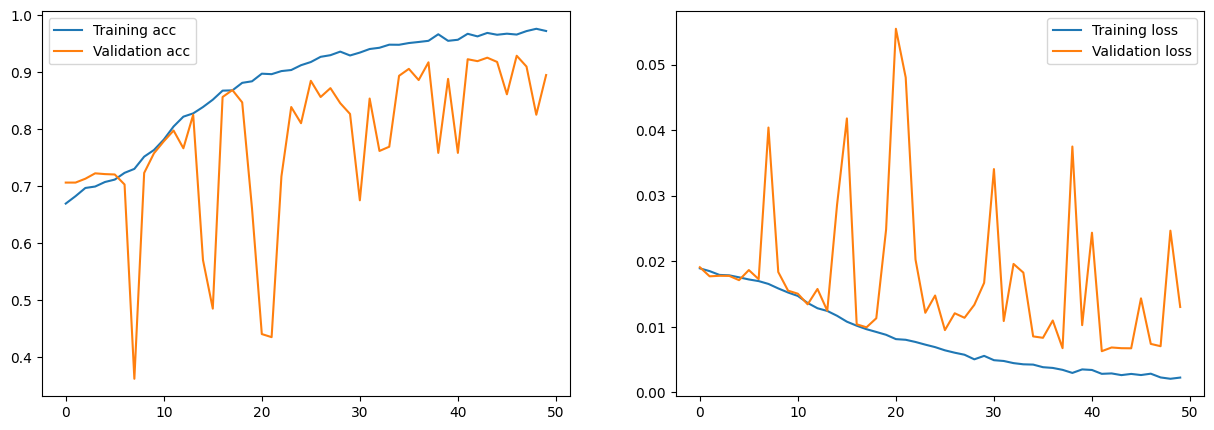

In [10]:
# PLOT THE ACCURACY on train and validation dataset
plot_results(binary_hist)